# Excercise 2

This notebook belongs to Shaakirah Sulaiman (SLMSHA047) and creates a file that contains the correct header, where variable names also includes the units.

Part 1 - Flat data and headers

In [1]:
import pandas as pd

df = pd.read_csv(
    "for_nitpicker.dat",
    sep="\t",
    header=None,
    names=["Date", "Time", "Depth (m)","Temperature (°C)","Salinity (g/kg)"]
)

df.to_csv("20260507_CTD_data.csv", index=False)

Part 2 - Profiles

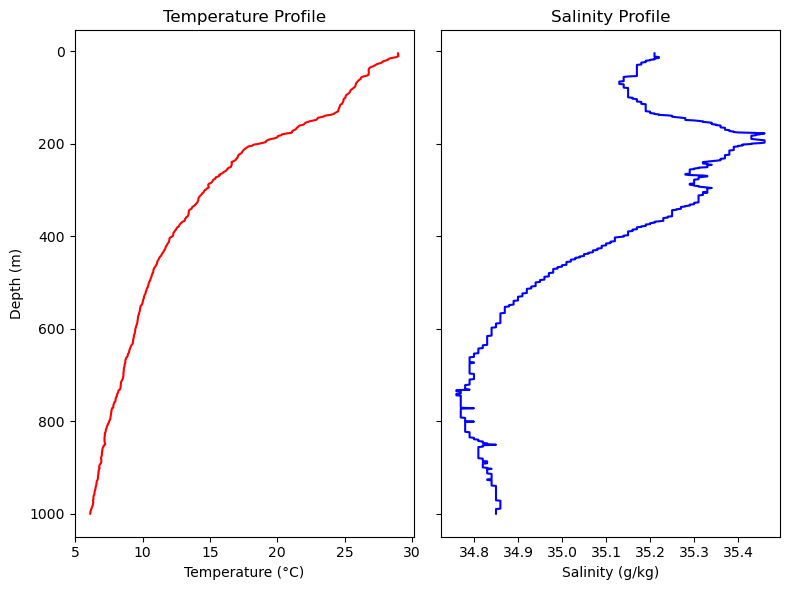

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(8, 6))

# Temperature plot
axes[0].plot(df["Temperature (°C)"], df["Depth (m)"], color="red")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Temperature Profile")

# Salinity plot
axes[1].plot(df["Salinity (g/kg)"], df["Depth (m)"], color="blue")
axes[1].set_xlabel("Salinity (g/kg)")
axes[1].set_title("Salinity Profile")

# In oceanography, depth increases downward
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

Part 3 - Time series

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# -------------------------------
# Function: ddmm to decimal degrees
# -------------------------------
def ddmm2dd(ddmm):
    """
    Converts a position input from degrees and minutes to degrees and decimals
    Input is ddmm.cccc and output is dd.cccc
    """
    thedeg = np.floor(ddmm / 100.)
    themin = (ddmm - thedeg * 100.) / 60.
    return thedeg + themin

In [14]:
# ── 1. Load the CSV from a local file ────────────────────────────────────────
SAA2_dat = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    parse_dates=["TIME_SERVER"],
    index_col="TIME_SERVER",
    na_values=[-9999, -999, 9999, "NaN", "nan", "NA", ""],
)

print("=== Raw data overview ===")
print(f"Shape            : {SAA2_dat.shape}")
print(f"Index dtype      : {SAA2_dat.index.dtype}")
print(f"Index start/end  : {SAA2_dat.index[0]}  →  {SAA2_dat.index[-1]}")
print(f"\nMissing values per column:\n{SAA2_dat.isna().sum()}\n")
print(SAA2_dat.head(3))

# ── 2. Subset: departure → 4 July 2017 (southernmost point) ──────────────────
subset = SAA2_dat.loc[: "2017-07-04"]
print(f"\nSubset shape : {subset.shape}")
print(f"Subset period: {subset.index[0]}  →  {subset.index[-1]}\n")

# ── Helper – resolve column names robustly ────────────────────────────────────
def find_col(df, candidates):
    """Return the first candidate that exists (case-insensitive)."""
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    raise KeyError(f"None of {candidates} found. Columns: {list(df.columns)}")

# ── Column mapping to actual CSV headers ─────────────────────────────────────
col_temp = find_col(subset, ["AIR_TEMPERATURE"])
col_sal  = find_col(subset, ["TSG_SALINITY"])
col_wspd = find_col(subset, ["WIND_SPEED_TRUE", "WIND_SPEED_REL"])
col_lat  = find_col(subset, ["LATITUDE"])

print(f"Columns used → T:{col_temp}  S:{col_sal}  Wspd:{col_wspd}  Lat:{col_lat}")

=== Raw data overview ===
Shape            : (2202, 16)
Index dtype      : datetime64[us]
Index start/end  : 2017-06-28 17:10:00  →  2017-07-14 00:00:00

Missing values per column:
id                   0
TIME_GPS           225
LATITUDE           225
N_S                225
LONGITUDE          225
E_W                225
HUMIDITY           225
BAROMETER          225
AIR_TEMPERATURE    225
WIND_SPEED_REL     225
WIND_SPEED_TRUE    228
WIND_DIR_REL       225
WIND_DIR_TRUE      228
PAR                226
TSG_SALINITY       339
TSG_TEMP           339
dtype: int64

                       id  TIME_GPS  LATITUDE N_S  LONGITUDE E_W  HUMIDITY  \
TIME_SERVER                                                                  
2017-06-28 17:10:00  1256  17:09:58  3428.595   S   1819.447   E      73.2   
2017-06-28 17:20:00  1257  17:19:58  3430.443   S   1820.241   E      65.2   
2017-06-28 17:30:00  1258  17:29:59  3432.261   S   1821.118   E      68.0   

                     BAROMETER  AIR_TEMPERATUR

In [17]:

# ── 3a. Time series of air temperature (grayscale style) ─────────────────────
with plt.style.context("grayscale"):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(subset.index, subset[col_temp], linewidth=0.8)
    ax.set_xlabel("Date (UTC)", fontsize=11)
    ax.set_ylabel("Air Temperature (°C)", fontsize=11)
    ax.set_title("SA Agulhas II – Air Temperature (departure → 4 July 2017)", fontsize=12)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=3))
    plt.xticks(rotation=30, ha="right")
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    fig.savefig("20260507_temperature_timeseries_grayscale.png", dpi=150)
    print("Saved: temperature_timeseries.png")
plt.close()


Saved: temperature_timeseries.png


In [18]:
# Histogram of salinity

sal_col = "TSG_SALINITY"

bins = np.arange(30, 35.5, 0.5)

plt.figure(figsize=(8, 5))
plt.hist(df_sel[sal_col].dropna(), bins=bins, edgecolor="black")
plt.xlabel("Salinity (psu)")
plt.ylabel("Frequency")
plt.title("Salinity Distribution")
plt.tight_layout()



plt.savefig("20260507_salinity_histogram.png", dpi=300)
plt.close()

In [19]:
# Statistics table

wind_col = "WIND_SPEED_TRUE"
air_col = "AIR_TEMPERATURE"
lat_col = "LATITUDE"

def iqr(x):
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)

stats = pd.DataFrame({
    "Mean": [df_sel[temp_col].mean(), df_sel[sal_col].mean()],
    "Std": [df_sel[temp_col].std(), df_sel[sal_col].std()],
    "IQR": [iqr(df_sel[temp_col]), iqr(df_sel[sal_col])]
}, index=["TSG_TEMP", "TSG_SALINITY"])

print("\nSummary statistics:")
print(stats)


Summary statistics:
                   Mean       Std      IQR
TSG_TEMP       9.245812  6.763438  13.8600
TSG_SALINITY  33.352330  0.737574   1.4742


In [13]:
# Scatter plot: wind vs air temp colored by latitude

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    df_sel[wind_col],
    df_sel[air_col],
    c=df_sel[lat_col],
    cmap="viridis",
    s=10
)
plt.colorbar(sc, label="Latitude")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Air Temperature (°C)")
plt.title("Wind Speed vs Air Temperature")
plt.tight_layout()
plt.savefig("20260507_wind_air_scatter.png", dpi=300)
plt.close()

References
OpenAI. (2026). ChatGPT (May 7 version) [Large language model]. https://chat.openai.com